### 01. Importing Dependencies

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import math
import matplotlib.pyplot as plt

### 02. Loading dataset

In [3]:
df = pd.read_csv("data/processed/estate_missing_values_handled.csv")
df.head()

,IncomeLevel,PropertyAge,TotalRooms,TotalBedrooms,NeighborhoodPop,AvgOccupancy,Latitude,Longitude,TargetPrice,RoomsPerHousehold,BedroomsRatio
0,3.287977,32.970198,5.128150,0.990769,2339.474039,3.739113,32.71,-117.03,1.030,1.359130,0.200576
1,3.804601,49.030192,4.372696,1.040469,1269.383596,1.429576,33.77,-118.16,3.821,2.573820,0.232703
2,2.029509,36.255617,4.131418,1.032285,1455.381923,3.914447,32.69,-117.11,0.934,1.002116,0.258269
3,3.540823,42.918534,6.270531,1.147146,895.050628,2.681969,36.78,-119.80,0.965,2.725400,0.180940
4,6.609324,20.212848,6.178103,0.986182,2698.088189,3.457448,37.42,-121.86,2.648,1.867161,0.160572


### 03. Plotting

#### 3.1 Distribution Plots

In [4]:
numerical_columns = [
    'IncomeLevel', 'PropertyAge', 'TotalRooms', 'TotalBedrooms',
    'NeighborhoodPop', 'AvgOccupancy', 'Latitude', 'Longitude',
    'TargetPrice', 'RoomsPerHousehold', 'BedroomsRatio'
]
categorical_columns = []

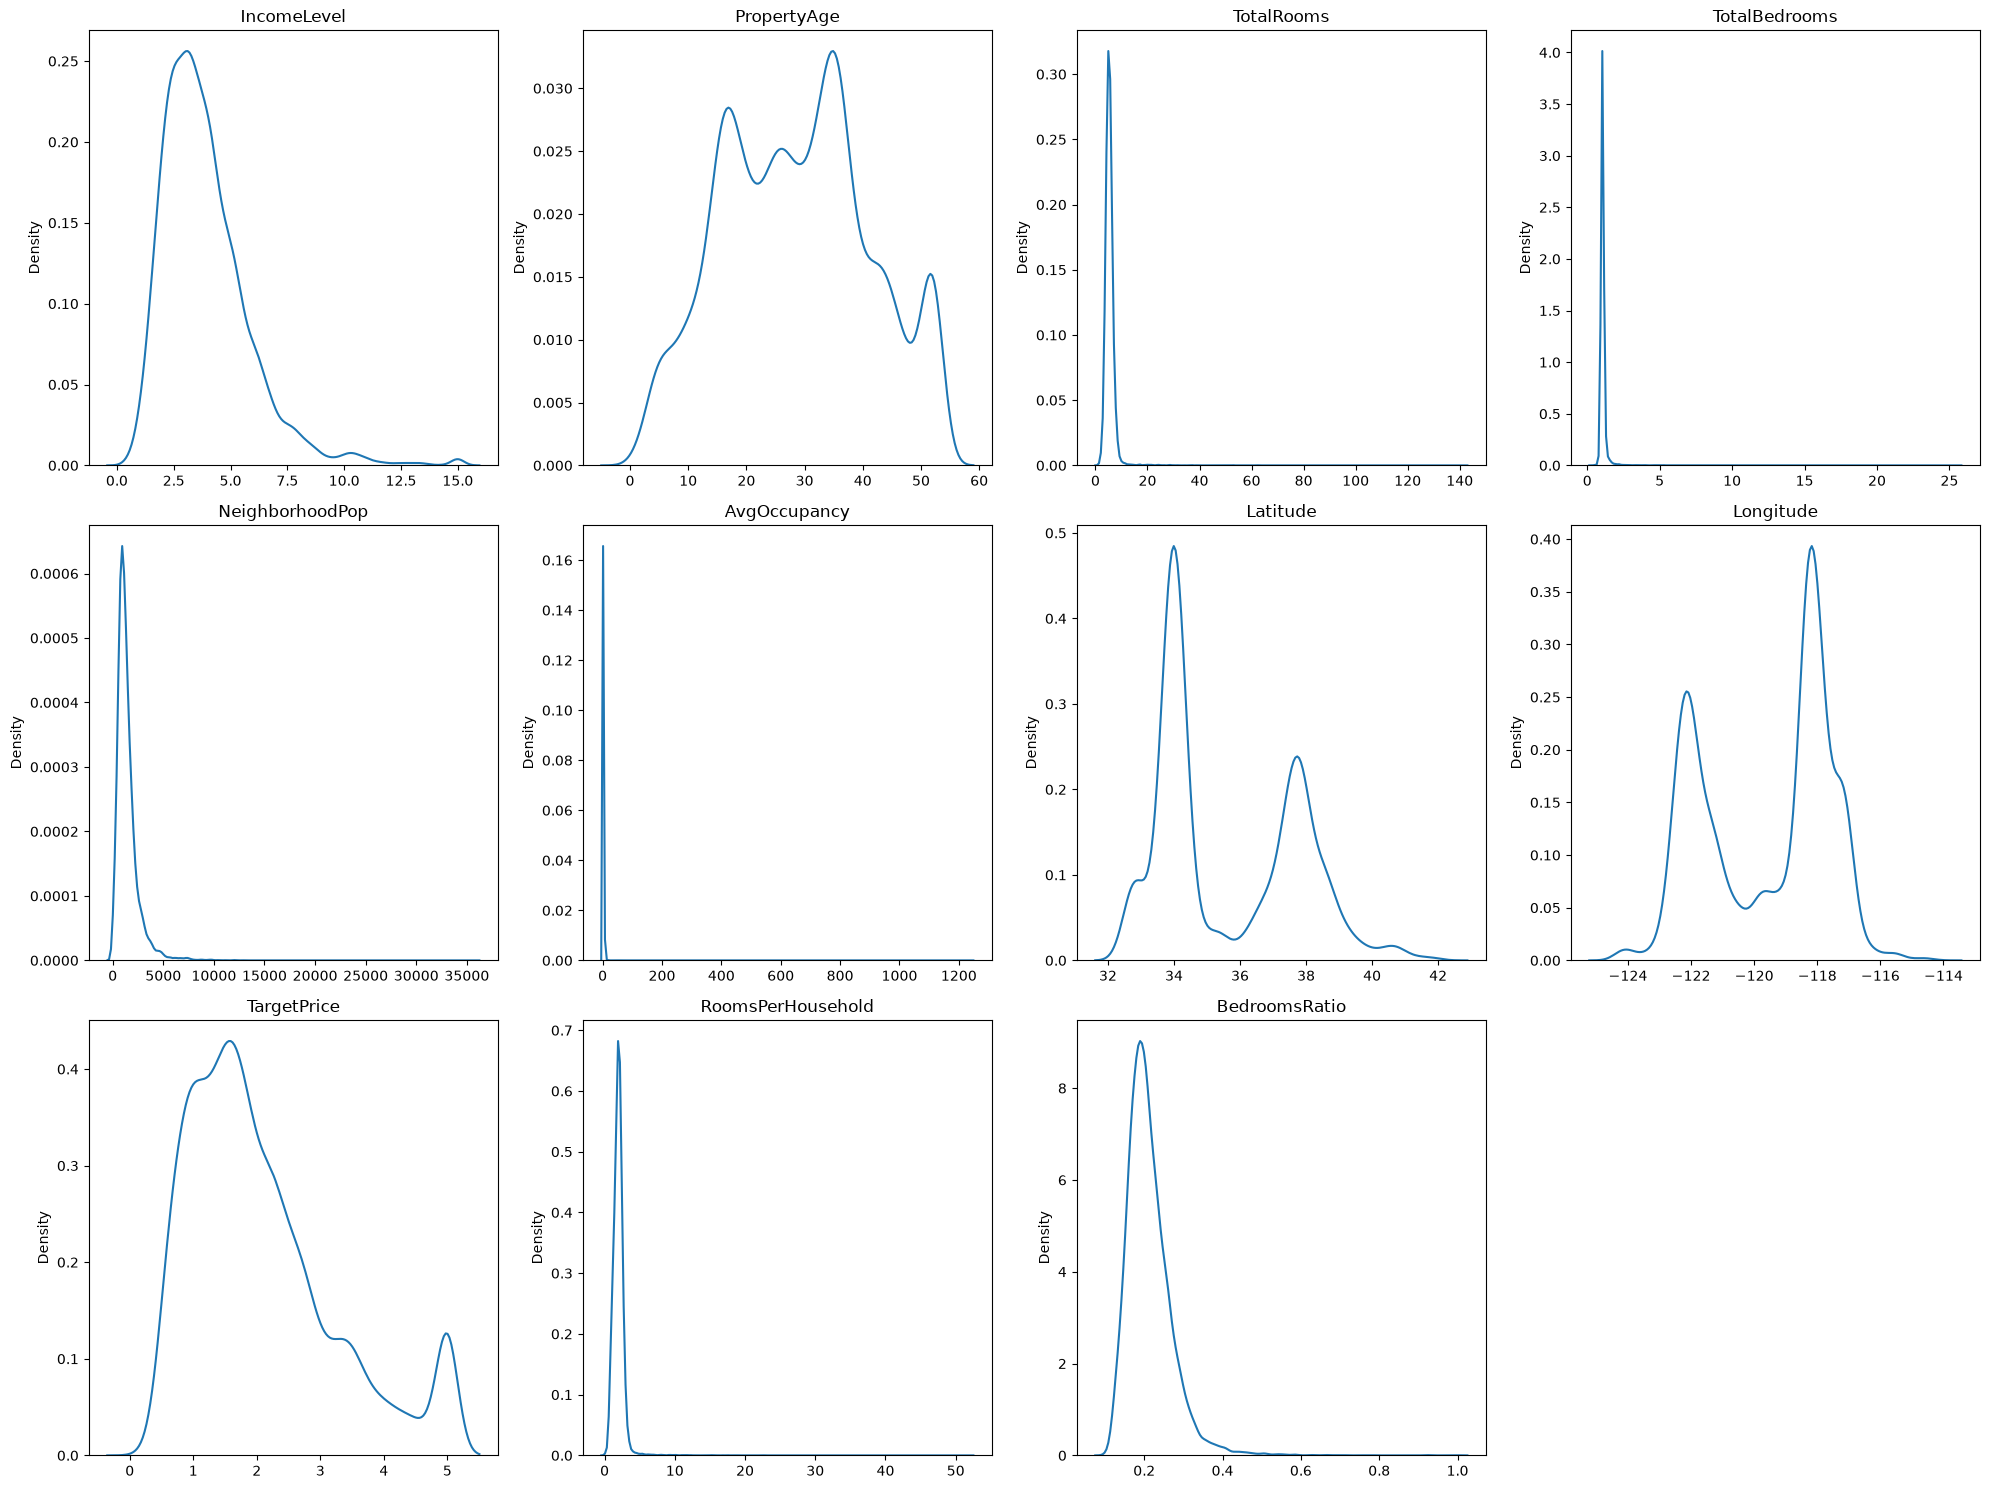

In [5]:
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.flatten()
for idx, col in enumerate(numerical_columns):
    sns.kdeplot(data=df[col], ax=axes[idx])
    axes[idx].set_title(col)
    axes[idx].set_xlabel('')

for j in range(len(numerical_columns), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


#### 3.2 Bar plot

In [10]:
sns.set(style="whitegrid")

if len(categorical_columns) > 0:
    n_cols = 4
    n_rows = math.ceil(len(categorical_columns) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows*5))
    if n_rows * n_cols == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    for i, col in enumerate(categorical_columns):
        counts = df[col].value_counts()
        axes[i].pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140, 
                    colors=sns.color_palette("pastel"))
        axes[i].set_title(f'{col} Distribution')
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])
    plt.tight_layout()
    plt.show()
else:
    print("No categorical columns to plot.")

No categorical columns to plot.


#### 3.3 Box plot

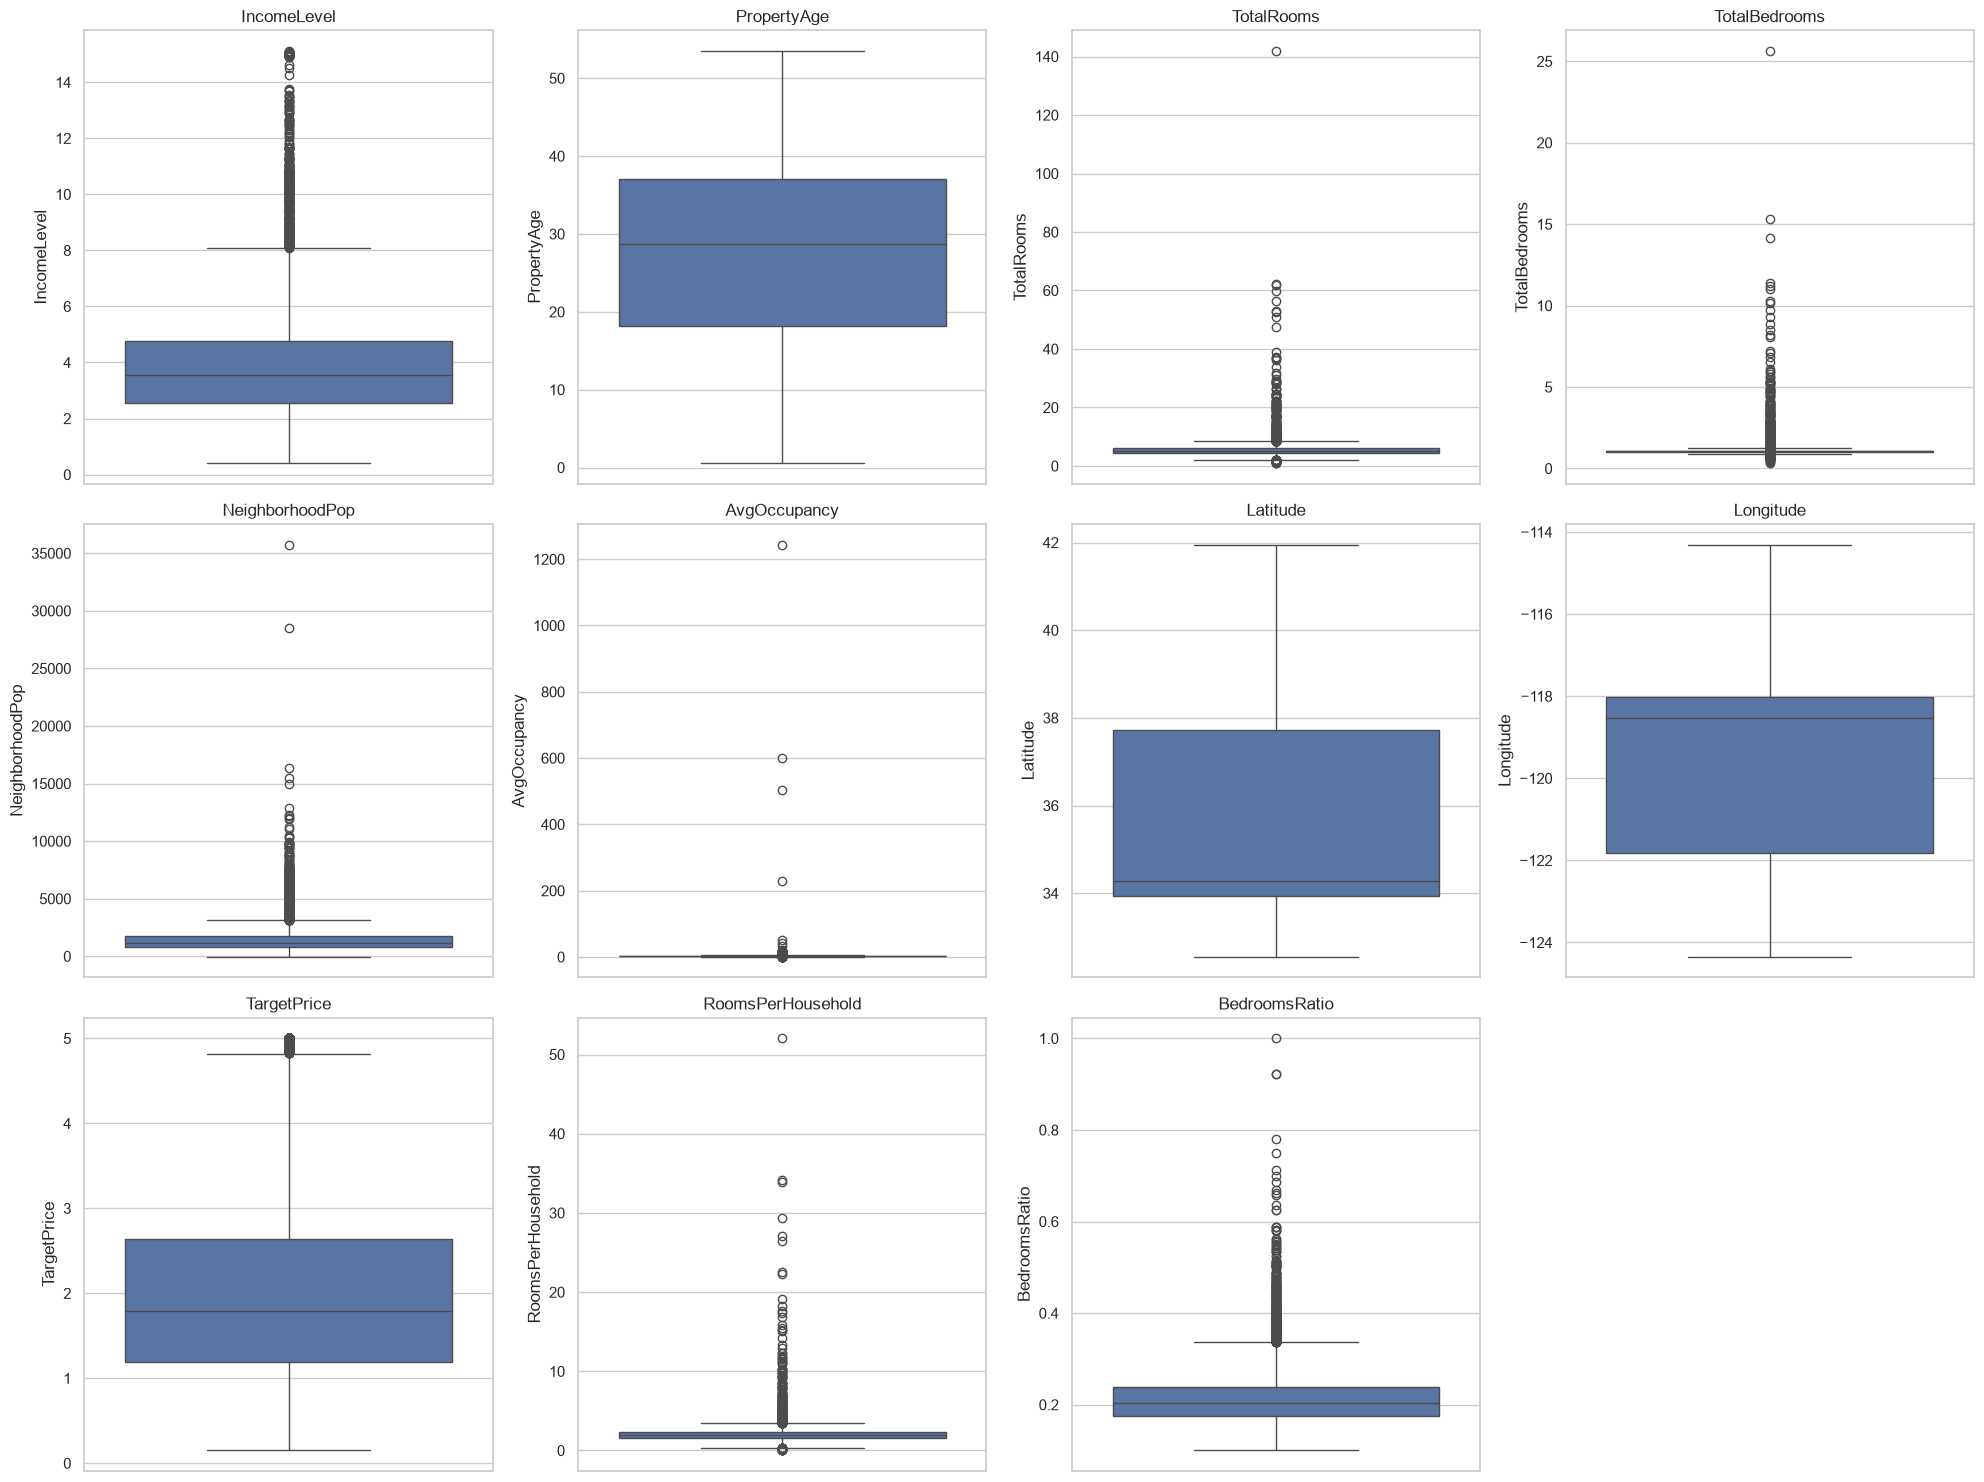

In [11]:
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.flatten()
for idx, col in enumerate(numerical_columns):
    sns.boxplot(data=df[col], ax=axes[idx])
    axes[idx].set_title(col)

for j in range(len(numerical_columns), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### 3.4  sigma Rule

In [12]:
def find_anomaly(data):
    mean = data.mean()
    std = data.std()

    upper_bound = mean + (3 * std)
    lower_bound = mean - (3 * std)

    return (data > upper_bound) | (data < lower_bound)

In [13]:
for col in numerical_columns:
    n_outliers = find_anomaly(df[col]).sum()
    n_outlier_percentage = round(n_outliers / len(df), 3)
    print(f"{col} : {n_outliers} outliers ({n_outlier_percentage} %)")

IncomeLevel : 260 outliers (0.017 %)
PropertyAge : 0 outliers (0.0 %)
TotalRooms : 100 outliers (0.007 %)
TotalBedrooms : 116 outliers (0.008 %)
NeighborhoodPop : 239 outliers (0.016 %)
AvgOccupancy : 6 outliers (0.0 %)
Latitude : 0 outliers (0.0 %)
Longitude : 0 outliers (0.0 %)
TargetPrice : 0 outliers (0.0 %)
RoomsPerHousehold : 103 outliers (0.007 %)
BedroomsRatio : 210 outliers (0.014 %)


#### 3.5 IQR method

In [14]:
def find_anomaly(data):
    Q1 = np.percentile(data, 25)
    Q3 = np.percentile(data, 75)

    IQR = Q3 - Q1 

    upper_bound = Q3 + 1.5 * IQR
    lower_bound = Q1 - 1.5 * IQR 

    return (data > upper_bound) | (data < lower_bound)

In [15]:
for col in numerical_columns:
    n_outliers = find_anomaly(df[col]).sum()
    n_outlier_percentage = round(n_outliers / len(df), 3)
    print(f"{col} : {n_outliers} outliers ({n_outlier_percentage} %)")

IncomeLevel : 474 outliers (0.031 %)
PropertyAge : 0 outliers (0.0 %)
TotalRooms : 373 outliers (0.025 %)
TotalBedrooms : 1003 outliers (0.066 %)
NeighborhoodPop : 879 outliers (0.058 %)
AvgOccupancy : 396 outliers (0.026 %)
Latitude : 0 outliers (0.0 %)
Longitude : 0 outliers (0.0 %)
TargetPrice : 795 outliers (0.052 %)
RoomsPerHousehold : 302 outliers (0.02 %)
BedroomsRatio : 449 outliers (0.03 %)
